### This file test the RePercENT model on synthetic data

In [13]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define imports here

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.models.perceiver import Perceiver
from src.models.repercent import DisenEncoder, RePercENT, DisenLoss
import math
from tqdm.notebook import tqdm

In [15]:
# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [16]:
N_data = 100000
latent_dim = {'Zs': 32, 'Z1': 32, 'Z2': 32}
mod_type= "random"  # "rbf", "random", "identity"
t1, t2 = 5, 10
gamma1, gamma2 = 2.0, 1.0
normalize = False
gen_data = GenerateData(N_data= N_data, mod_type= mod_type, latent_dims= latent_dim)
# gen_data.set_seed(0, device= device)
gen_data.create_dataset(t1= t1, t2= t2, gamma1= gamma1, gamma2= gamma2, normalize= normalize)
gen_data.print_dataset_info()

Modulation matrices not found, creating with default parameters for each modality.
before normalization sample: [[ 0.06801077 -0.04832933  0.10398522 -0.00276612 -0.02293166]
 [ 0.01740567 -0.01814889  0.08054221 -0.0356492  -0.13771405]
 [ 0.0259857  -0.00583425  0.08563353 -0.0407453   0.02332554]
 [ 0.0263554   0.00924267 -0.03924767  0.00703883  0.16283036]
 [-0.04473308 -0.00873864  0.15236844  0.01318829  0.02548309]]
after normalization sample: [[ 0.06801077 -0.04832933  0.10398522 -0.00276612 -0.02293166]
 [ 0.01740567 -0.01814889  0.08054221 -0.0356492  -0.13771405]
 [ 0.0259857  -0.00583425  0.08563353 -0.0407453   0.02332554]
 [ 0.0263554   0.00924267 -0.03924767  0.00703883  0.16283036]
 [-0.04473308 -0.00873864  0.15236844  0.01318829  0.02548309]]
X1 shape: (100000, 5, 64), X2 shape: (100000, 10, 64)
Dataset Information:
Number of samples: 100000
Modality 1 data shape: 100000
Labels 1 shape: (100000,), Unique classes: [0 1]
Labels 2 shape: (100000,), Unique classes: [0 1]

In [17]:
dataset = MultimodalDataset(total_data= gen_data.dataset_dict['total_data'], labels_1 = gen_data.dataset_dict['labels_1'], labels_2=gen_data.dataset_dict['labels_2'], labels_s=gen_data.dataset_dict['labels_s'])

### Initialize the encoders for each modality:

$M_1$

In [18]:
# We want be using encoders for the synthetic data experiments, so we define identity encoders
enc_m1 = nn.Identity()

# Initialize the Perceiver module
DEPTH = 4
MAX_FREQ = math.ceil(t1 / 2) # set max freq to Nyquist frequency
NUM_FREQ_BANDS = 3
INPUT_CHANNELS= latent_dim['Z1'] + latent_dim['Zs'] # input channels = dim of unique component 1 + dim of shared component
INPUT_AXIS = 1 
LATENT_HEADS = 1
NUM_LATENTS = 2 # number of latent vectors, i.e. the number of disentangled factors to extract
LATENT_DIM = 32
CROSS_HEADS = 4
POS_ENCODING= True


per_m1 = Perceiver(num_freq_bands= NUM_FREQ_BANDS,
                    latent_dim= LATENT_DIM,
                    num_latents= NUM_LATENTS,
                  depth= DEPTH,
                  max_freq= MAX_FREQ,
                  latent_heads= LATENT_HEADS,
                  cross_heads= CROSS_HEADS,
                  input_channels= INPUT_CHANNELS,
                  input_axis= INPUT_AXIS,
                  fourier_encode_data= POS_ENCODING).to(device)

dissen_m1 = DisenEncoder(encoder_model= enc_m1, perceiver_model= per_m1).to(device)
dissen_m1.__repr__()

DisenEncoder with encoder: Identity() and perceiver: Perceiver(
  (layers): ModuleList(
    (0-3): 4 x ModuleList(
      (0): PreNorm(
        (fn): Attention(
          (to_q): Linear(in_features=32, out_features=256, bias=False)
          (to_kv): Linear(in_features=71, out_features=512, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_out): Linear(in_features=256, out_features=32, bias=True)
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm_context): LayerNorm((71,), eps=1e-05, elementwise_affine=True)
      )
      (1): PreNorm(
        (fn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=256, bias=True)
            (1): GEGLU()
            (2): Linear(in_features=128, out_features=32, bias=True)
            (3): Dropout(p=0.0, inplace=False)
          )
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (2): ModuleList(
  

$M_2$

In [19]:
# We want be using encoders for the synthetic data experiments, so we define identity encoders
enc_m2 = nn.Identity()

# Initialize the Perceiver module
DEPTH = 4
MAX_FREQ = math.ceil(t2 / 2) # set max freq to Nyquist frequency
NUM_FREQ_BANDS = math.floor(math.log2(MAX_FREQ)) + 1
INPUT_CHANNELS= latent_dim['Z2'] + latent_dim['Zs'] # input channels = dim of unique component 2 + dim of shared component
INPUT_AXIS = 1 # input axis = time points of modality 2
LATENT_HEADS = 1
NUM_LATENTS = 2 # number of latent vectors, i.e. the number of disentangled factors to extract
LATENT_DIM = 32
CROSS_HEADS = 4
POS_ENCODING= True


per_m2 = Perceiver(num_freq_bands= NUM_FREQ_BANDS,
                  latent_dim= LATENT_DIM,
                  num_latents= NUM_LATENTS,
                  depth= DEPTH,
                  max_freq= MAX_FREQ,
                  latent_heads= LATENT_HEADS,
                  cross_heads= CROSS_HEADS,
                  input_channels= INPUT_CHANNELS,
                  input_axis= INPUT_AXIS,
                  fourier_encode_data= POS_ENCODING).to(device)

dissen_m2 = DisenEncoder(encoder_model= enc_m2, perceiver_model= per_m2).to(device)
dissen_m2.__repr__()


DisenEncoder with encoder: Identity() and perceiver: Perceiver(
  (layers): ModuleList(
    (0-3): 4 x ModuleList(
      (0): PreNorm(
        (fn): Attention(
          (to_q): Linear(in_features=32, out_features=256, bias=False)
          (to_kv): Linear(in_features=71, out_features=512, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_out): Linear(in_features=256, out_features=32, bias=True)
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm_context): LayerNorm((71,), eps=1e-05, elementwise_affine=True)
      )
      (1): PreNorm(
        (fn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=256, bias=True)
            (1): GEGLU()
            (2): Linear(in_features=128, out_features=32, bias=True)
            (3): Dropout(p=0.0, inplace=False)
          )
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (2): ModuleList(
  

### Define the complete module

In [20]:
model = RePercENT(M= 2, disenEncoder= [dissen_m1, dissen_m2]).to(device)

### Tesing fwd pass and Augmentations in data

In [21]:
dataloader = DataLoader(dataset, batch_size= 16, shuffle= True)

for batch_idx, (data_m1, data_m2, labels_1, labels_2, labels_s) in enumerate(dataloader):
    data_m1 = data_m1.to(device)
    data_m2 = data_m2.to(device)
    print("Testing augmentation")

    data_m1_aug = gen_data.augment_data(data_m1, aug_type= "noise", scale= 0.0001)
    data_m1_random_drop = gen_data.augment_data(data_m1, aug_type= "random_drop", drop_scale= 10)
    data_1_swap = gen_data.augment_data(data_m1, aug_type= "swap")
    print("Original Data Modality 1:", data_m1[0, 0, :])
    print("Augmented Data Modality 1 (Noise):", data_m1_aug[0, 0, :])
    print("Augmented Data Modality 1 (Random Drop):", data_m1_random_drop[0, 0, :])
    print("Augmented Data Modality 1 (Swap):", data_1_swap[0, 0, :])
    # outputs = model(data_m1, data_m2)
    # print(f"Batch {batch_idx+1}:")
    # for i, (output, val) in enumerate(outputs.items()):
    #     print(f" Model output {i+1} - {output}: {val}")
    break  # Just process one batch for demonstration

Testing augmentation
Original Data Modality 1: tensor([-2.2441e-02,  2.9429e-02, -1.0122e-02,  7.3835e-03,  2.7412e-03,
         6.4335e-02, -4.4736e-02,  2.0901e-02, -2.6390e-04, -4.5004e-02,
         2.7855e-03,  1.7626e-03, -6.7040e-02, -1.7000e-01, -1.9346e-02,
        -4.4276e-02,  4.4312e-02, -1.5403e-01, -6.7751e-02,  6.4329e-03,
        -9.6664e-02,  3.0743e-05, -6.0704e-04, -9.7662e-02,  1.3885e-02,
        -1.7864e-02, -3.8007e-02,  5.8236e-03, -2.0785e-01, -7.0535e-02,
         3.7169e-02, -3.8289e-04,  1.3588e-01, -7.0449e-02, -4.4777e-02,
        -1.8898e-02,  3.9078e-02, -4.3582e-02, -5.4723e-03,  8.1579e-03,
         1.7371e-02,  2.3261e-01, -4.9820e-02, -7.1414e-02, -7.0670e-02,
         1.5399e-01, -2.0194e-01, -1.9472e-02,  4.6155e-02,  7.3436e-02,
         9.4985e-04,  1.7834e-02,  1.3208e-01, -3.8958e-02,  1.5380e-02,
        -6.6414e-03, -1.0671e-01,  1.3136e-02, -1.0861e-02, -2.0837e-02,
         2.8743e-01,  2.5254e-02,  3.8646e-03, -8.9828e-03], device='cuda:0')

### Define training loop

In [22]:
# Training loop with logistic regression probing for disentanglement evaluation
# set seed for torch
torch.manual_seed(0)
# clear memory
torch.cuda.empty_cache()
# Training hyperparameters
alpha = 0.5
lmd = 0.001
dissen_loss = DisenLoss(alpha=alpha, lmd=lmd)
EPOCHS = 100
BATCH_SZ = 4048
LR = 0.01
dataloader = DataLoader(dataset, batch_size=BATCH_SZ, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Training logs
train_loss_logs = {
    "loss": [], "loss_ortho": [], "loss_unique": [], "loss_shared": [],
    "acc_u12_l1": [], "acc_s21_ls": [], "acc_u21_l2": [], "acc_s12_ls": []
}

print(f"Training with device: {device}\n")

# Training loop
for _iter in range(EPOCHS):
    epoch_loss = 0.0
    epoch_ortho_loss = 0.0
    epoch_unique_loss = 0.0
    epoch_shared_loss = 0.0
    
    model.train()
    
    print(f"----- Epoch: {_iter + 1} / {EPOCHS} -----")
    
    # Training phase
    for batch_idx, (data_m1, data_m2, _, _, _) in enumerate(dataloader):
        temp_b = data_m1.shape[0]
        # print(f"  Batch: {batch_idx + 1} / {len(dataloader)}", end='\r')
        data_m1 = data_m1.to(device)
        data_m2 = data_m2.to(device)
        
        # print(f"M1: {data_m1[0, 0, -3:]}, M2: {data_m2[0, 0, -3:]}")
        # Augment data 
        data_m1_aug = gen_data.augment_data(data_m1, aug_type="swap")
        data_m2_aug = gen_data.augment_data(data_m2, aug_type="swap")
        
        # Forward pass through RePercENT
        outputs = model(data_m1, data_m2)
        outputs_aug = model(data_m1_aug, data_m2_aug)
        
        # Compute disentanglement loss
        loss_train, logs_train = dissen_loss(outputs, outputs_aug)
        
        # Backward pass for RePercENT
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        # Track losses
        epoch_loss += loss_train.item()/ temp_b
        epoch_ortho_loss += logs_train["ortho"]/ temp_b
        epoch_unique_loss += logs_train["unique"]/ temp_b
        epoch_shared_loss += logs_train["shared"]/ temp_b
    
    # Epoch statistics
    avg_epoch_loss = epoch_loss / len(dataloader)
    avg_ortho_loss = epoch_ortho_loss / len(dataloader)
    avg_unique_loss = epoch_unique_loss / len(dataloader)
    avg_shared_loss = epoch_shared_loss / len(dataloader)
    
    # Log results
    train_loss_logs["loss"].append(avg_epoch_loss)
    train_loss_logs["loss_ortho"].append(avg_ortho_loss)
    train_loss_logs["loss_unique"].append(avg_unique_loss)
    train_loss_logs["loss_shared"].append(avg_shared_loss)
    

    print(f"  Loss(x 100): {avg_epoch_loss* 100:.5f} | Ortho (x 100): {avg_ortho_loss* 100:.5f} | Unique (x 100): {avg_unique_loss* 100:.5f} | Shared (x 100): {avg_shared_loss* 100:.5f}")
    # print(f"  Acc u_12→l1: {acc_u12_l1:.1f}% | s_21→ls: {acc_s21_ls:.1f}% | u_21→l2: {acc_u21_l2:.1f}% | s_12→ls: {acc_s12_ls:.1f}%\n")

print("Training complete!")

Training with device: cuda

----- Epoch: 1 / 100 -----
  Loss(x 100): 0.49901 | Ortho (x 100): 153.93167 | Unique (x 100): 0.18568 | Shared (x 100): 0.21239
----- Epoch: 2 / 100 -----
  Loss(x 100): 0.43069 | Ortho (x 100): 91.92522 | Unique (x 100): 0.18293 | Shared (x 100): 0.20834
----- Epoch: 3 / 100 -----
  Loss(x 100): 0.36551 | Ortho (x 100): 34.92751 | Unique (x 100): 0.17503 | Shared (x 100): 0.20418
----- Epoch: 4 / 100 -----
  Loss(x 100): 0.29547 | Ortho (x 100): 19.26611 | Unique (x 100): 0.12232 | Shared (x 100): 0.17658
----- Epoch: 5 / 100 -----
  Loss(x 100): 0.20069 | Ortho (x 100): 25.06567 | Unique (x 100): 0.05526 | Shared (x 100): 0.11790
----- Epoch: 6 / 100 -----
  Loss(x 100): 0.11052 | Ortho (x 100): 14.39333 | Unique (x 100): 0.01829 | Shared (x 100): 0.06752
----- Epoch: 7 / 100 -----
  Loss(x 100): 0.04921 | Ortho (x 100): 7.44098 | Unique (x 100): 0.00705 | Shared (x 100): 0.02957
----- Epoch: 8 / 100 -----
  Loss(x 100): 0.02661 | Ortho (x 100): 5.29222 |

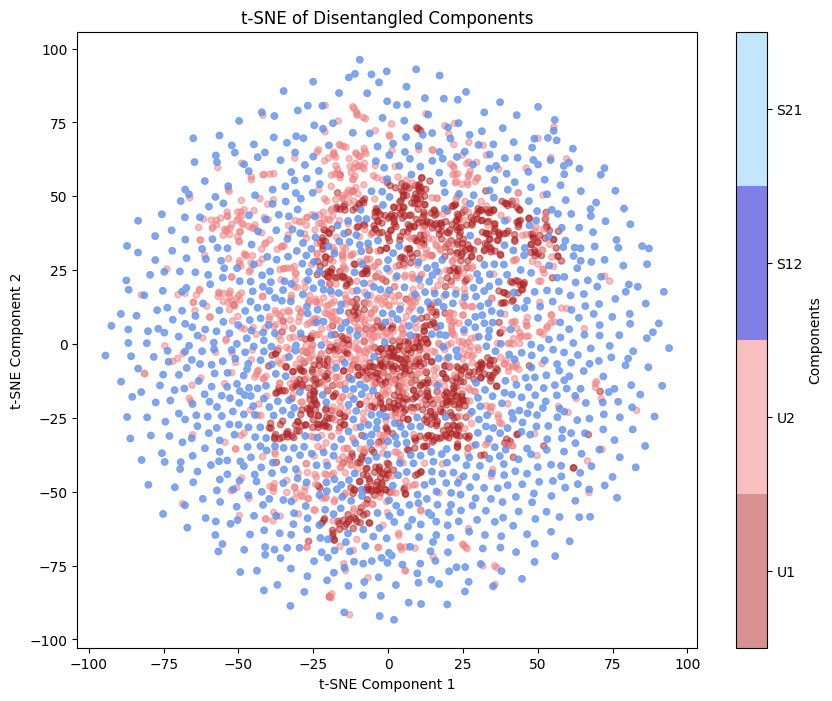

In [26]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap


# Extract the disentangled components from the trained model
model.eval()

# Use a batch from the dataset for visualization
dataloader_viz = DataLoader(dataset, batch_size=1000, shuffle=False)
data_m1_viz, data_m2_viz, _, _, _ = next(iter(dataloader_viz))

data_m1_viz = data_m1_viz.to(device)
data_m2_viz = data_m2_viz.to(device)

# Forward pass to extract disentangled components
with torch.no_grad():
    outputs_viz = model(data_m1_viz, data_m2_viz)
    
    # Extract components
    z_1 = outputs_viz['Z1'][0].cpu().numpy()  # Unique component from modality 1
    z_2 = outputs_viz['Z2'][0].cpu().numpy()  # Unique component from modality 2
    s_12 = outputs_viz['Z1'][1].cpu().numpy() # shared component from modality 1
    s_21 = outputs_viz['Z2'][1].cpu().numpy() # shared component from modality 2
    
    labels = [0] * z_1.shape[0] + [1] * z_2.shape[0] + s_12.shape[0] * [2] + s_21.shape[0] * [3]

    # t-SNE 2D visualization
    # Concatenate all components for t-SNE
    concat = np.concatenate([z_1, z_2, s_12, s_21], axis=0)

    # t-SNE 2D visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(concat)

    plt.figure(figsize=(10, 8))
    colors = ['#b22222', '#f08080', '#0000cd', '#87cefa']  # dark red, light red, dark blue, light blue


    # Create colormap
    cmap = ListedColormap(colors)
    scatter3 = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap= cmap, alpha=0.5, s= 20)

    # Discrete colorbar for four labels
    cbar = plt.colorbar(scatter3, ticks=[0, 1, 2, 3], boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5])
    cbar.set_label('Components')
    cbar.set_ticklabels(['U1', 'U2', 'S12', 'S21'])

    plt.title('t-SNE of Disentangled Components')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.show()

In [30]:
import pickle

results_dir = '../results/repercent_synthetic/'
os.makedirs(results_dir, exist_ok=True)
# Save the trained model weights as pickle file
model_path = os.path.join(results_dir, 'repercent_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model.state_dict(), f)

# Save training logs as pickle file
logs_path = os.path.join(results_dir, 'training_logs.pkl')
with open(logs_path, 'wb') as f:
    pickle.dump(train_loss_logs, f)

print(f"Model saved to: {model_path}")
print(f"Training logs saved to: {logs_path}")

Model saved to: ../results/repercent_synthetic/repercent_model.pkl
Training logs saved to: ../results/repercent_synthetic/training_logs.pkl


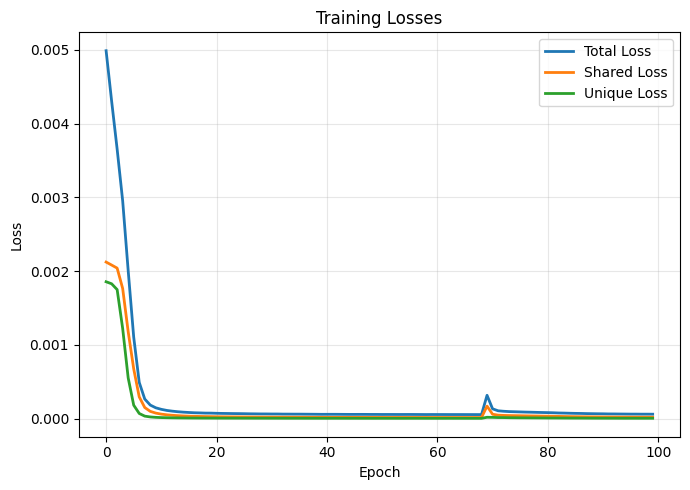

In [27]:
import matplotlib.pyplot as plt

# Plot training losses and accuracies
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Loss components
axes.plot(train_loss_logs["loss"], label="Total Loss", linewidth=2)
axes.plot(train_loss_logs["loss_shared"], label="Shared Loss", linewidth=2)
axes.plot(train_loss_logs["loss_unique"], label="Unique Loss", linewidth=2)
# axes.plot(train_loss_logs["loss_ortho"], label="Ortho Loss", linewidth=2)

axes.set_xlabel("Epoch")
axes.set_ylabel("Loss")
axes.set_title("Training Losses")
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
